# Sprint 4 – Integración, Despliegue y Gobernanza

**Olist Revenue Forecast** · Forecast de ingresos mensuales (`monthly_revenue`).

Este notebook demuestra los entregables del Sprint 4:
1. Forecast operativo desde el pipeline de predicción.
2. **Análisis SHAP** del aporte de variables (global + local).
3. **Métricas de negocio / ROI** (ahorro de tiempo, impacto).
4. Resumen de **gobernanza** (MLflow, gate de promoción, drift, ética).

> Docker, MLflow y la documentación de gobernanza se detallan en `docs/MLFLOW.md`,
> `docs/ETHICS_GOVERNANCE.md` y `docker-compose.yml`.

In [1]:
import sys
from pathlib import Path

# Asegura que la raíz del proyecto esté en el path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')

from src.utils.helpers import load_config, load_model, load_dataframe
cfg = load_config()
print('Proyecto:', cfg['project']['name'], '| target:', cfg['project']['target'])

Proyecto: olist_revenue_forecast | target: monthly_revenue


## 1. Forecast operativo

Carga el modelo final y genera el forecast de los próximos meses con intervalos.

In [2]:
from src.pipeline.predict_pipeline import PredictPipeline

forecast = PredictPipeline(cfg).run(horizon=3)
forecast

2026-06-17 00:38:00.563 | INFO     | src.pipeline.predict_pipeline:load_artifacts:47 - Cargando artefactos del modelo…


2026-06-17 00:38:01.096 | INFO     | src.pipeline.predict_pipeline:load_artifacts:51 - Modelo cargado con 5 features


2026-06-17 00:38:01.203 | INFO     | src.pipeline.predict_pipeline:load_latest_monthly:62 - Tabla mensual cargada desde caché (20 meses)


2026-06-17 00:38:01.211 | DEBUG    | src.features.cleaning:transform:57 -   monthly_orders: 2 valores clipados


2026-06-17 00:38:01.213 | DEBUG    | src.features.cleaning:transform:57 -   monthly_customers: 2 valores clipados


...

2026-06-17 00:38:02.932 | INFO     | src.pipeline.predict_pipeline:generate_forecast:125 - 
Forecast para los próximos 3 meses:


2026-06-17 00:38:02.933 | INFO     | src.pipeline.predict_pipeline:generate_forecast:127 -   Aug 2018: R$ 1,305,752.60 [1,151,797.43 – 1,459,707.78]


2026-06-17 00:38:02.934 | INFO     | src.pipeline.predict_pipeline:generate_forecast:127 -   Sep 2018: R$ 1,291,812.23 [1,017,427.57 – 1,566,196.89]


2026-06-17 00:38:02.938 | INFO     | src.pipeline.predict_pipeline:generate_forecast:127 -   Oct 2018: R$ 1,416,835.27 [1,090,412.70 – 1,743,257.83]


,ds,yhat,yhat_lower,yhat_upper,mape_target
0,2018-08-01,1.305753e+06,1.151797e+06,1.459708e+06,10.0
1,2018-09-01,1.291812e+06,1.017428e+06,1.566197e+06,10.0
2,2018-10-01,1.416835e+06,1.090413e+06,1.743258e+06,10.0


## 2. Explicabilidad con SHAP

El modelo final es un `LightGBMForecaster` (wrapper con un estimador por horizonte).
Para SHAP se extrae el modelo del horizonte 1 (predicción a 1 mes) y se usa
`TreeExplainer`, nativamente compatible con LightGBM.

In [3]:
from src.features.cleaning import clean_monthly_table
from src.evaluation.shap_analysis import (
    compute_shap_values, shap_summary_df, local_contributions_df, save_shap_plots,
)

forecaster = load_model('lgbm_forecaster', cfg)
clean_pipe = load_model('cleaning_pipeline', cfg)
monthly    = load_dataframe('monthly_features', cfg)

monthly_clean, _ = clean_monthly_table(monthly, cfg, fit=False, pipeline=clean_pipe)
X = monthly_clean[forecaster.feature_cols_]

shap_values, fnames, base = compute_shap_values(forecaster, X, horizon=1)
print(f'Valor base (esperado) del modelo: R$ {base:,.2f}')
shap_summary_df(shap_values, fnames).head(10)

2026-06-17 00:38:03.024 | DEBUG    | src.features.cleaning:transform:57 -   monthly_orders: 2 valores clipados


2026-06-17 00:38:03.028 | DEBUG    | src.features.cleaning:transform:57 -   monthly_customers: 2 valores clipados


2026-06-17 00:38:03.031 | DEBUG    | src.features.cleaning:transform:57 -   monthly_items: 2 valores clipados


2026-06-17 00:38:03.033 | DEBUG    | src.features.cleaning:transform:57 -   avg_ticket: 2 valores clipados


2026-06-17 00:38:03.036 | DEBUG    | src.features.cleaning:transform:57 -   median_ticket: 2 valores clipados


...

2026-06-17 00:38:03.161 | INFO     | src.features.cleaning:clean_monthly_table:310 - Limpieza aplicada (transform)


2026-06-17 00:38:05.017 | INFO     | src.evaluation.shap_analysis:build_explainer:64 - SHAP TreeExplainer creado para horizonte h=1


2026-06-17 00:38:05.025 | INFO     | src.evaluation.shap_analysis:compute_shap_values:112 - SHAP calculado: 20 obs × 5 features (base=930,410.43)


Valor base (esperado) del modelo: R$ 930,410.43


,feature,mean_abs_shap
0,monthly_orders,347716.268663
1,quarter,145122.840512
2,month_sin,105990.610074
3,avg_delay_days,79471.204020
4,month,18826.566470


2026-06-17 00:38:05.152 | INFO     | src.evaluation.shap_analysis:build_explainer:64 - SHAP TreeExplainer creado para horizonte h=1


2026-06-17 00:38:05.953 | INFO     | src.evaluation.shap_analysis:save_shap_plots:207 - Gráficos SHAP guardados: ['reports\\sprint4_shap_summary.png', 'reports\\sprint4_shap_bar.png']


Guardados: ['reports\\sprint4_shap_summary.png', 'reports\\sprint4_shap_bar.png']


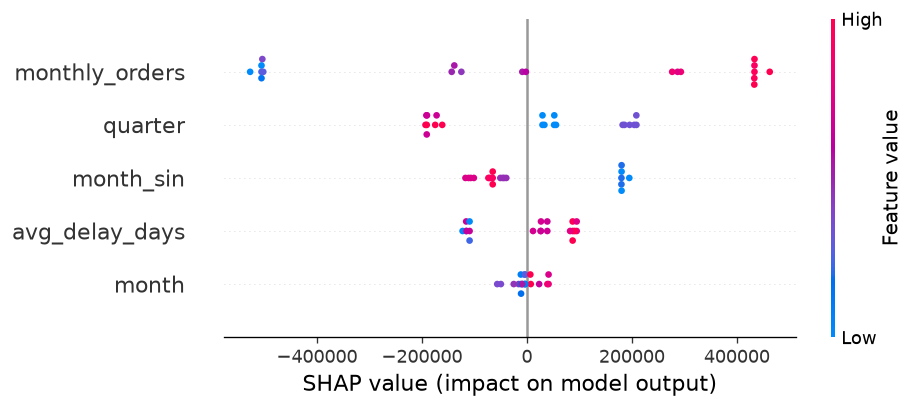

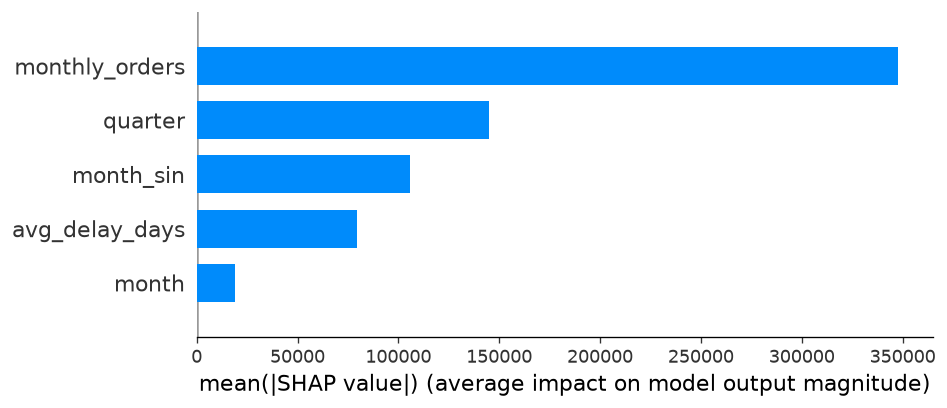

In [4]:
# Gráficos SHAP (beeswarm + barra) guardados en reports/
paths = save_shap_plots(forecaster, X)
print('Guardados:', paths)

from IPython.display import Image, display
for p in paths:
    display(Image(filename=str(ROOT / p)))

In [5]:
# Explicación local del último mes observado
local_contributions_df(shap_values, fnames, index=-1).head(10)

,feature,shap_value
0,monthly_orders,293278.483256
1,month_sin,180032.274525
2,quarter,-172077.308112
3,avg_delay_days,82261.135906
4,month,-8152.413732


## 3. Métricas de negocio y ROI

El ROI combina ahorro de tiempo (automatización del forecast manual) e impacto por
exactitud frente al mejor baseline. Los supuestos son editables en
`config.yaml → business`.

In [6]:
from src.evaluation.metrics import compute_roi_metrics
import pandas as pd

roi = compute_roi_metrics(forecast, monthly, cfg)
pd.Series(roi).to_frame('valor')

2026-06-17 00:38:06.038 | INFO     | src.evaluation.metrics:compute_roi_metrics:211 - ROI estimado: ahorro tiempo R$ 15,360/año + exactitud R$ 0/año = R$ 15,360/año


,valor
time_saved_hours_per_year,1.920000e+02
time_saving_brl_per_year,1.536000e+04
mape_improvement_pts,0.000000e+00
accuracy_saving_brl_per_year,0.000000e+00
total_benefit_brl_per_year,1.536000e+04
projected_revenue_horizon,4.014400e+06
forecast_horizon_months,3.000000e+00


> **Lectura honesta:** el MAPE de backtest del modelo (~10.1%) no supera al mejor
> baseline (Media Móvil 3M, 7.12%), por lo que el ahorro por exactitud es ~0. El
> valor principal del modelo es la **automatización** (ahorro de tiempo del analista)
> y el **forecast multi-horizonte con intervalos**, no la ganancia de exactitud sobre
> una media móvil. Ver `docs/ETHICS_GOVERNANCE.md`.

## 4. Gobernanza (resumen)

| Aspecto | Implementación |
|---|---|
| Versionado / tracking | **MLflow** (`scripts/run_mlflow_training.py`, `docs/MLFLOW.md`) |
| Gate de promoción | MAPE backtest < 10% y sin degradación vs campeón |
| Monitoreo de drift | **PSI** (umbral 0.25) en `src/features/selection.py` |
| Explicabilidad | **SHAP** (este notebook, `/api/v1/shap`, pestaña dashboard) |
| Despliegue | **Docker** (`docker compose up`): API:8000, Dashboard:8501, MLflow:5000 |
| Ética / privacidad | Datos anonimizados y agregados; ver `docs/ETHICS_GOVERNANCE.md` |

**Flujo de retraining mensual:** actualización incremental (`forecaster.update`)
para el forecast del mes + reentrenamiento completo periódico con nuevo run MLflow,
promoviendo solo si pasa el gate de MAPE.